In [180]:
import heapq
import os
import sys
from multiprocessing import Pool, cpu_count
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
import torch
import wandb
from gph import ripser_parallel
from gtda.homology._utils import _postprocess_diagrams
from gtda.plotting import plot_diagram, plot_point_cloud
from persim import plot_diagrams  # Plotting
from plotly import graph_objects as go
from ripser import ripser
from safetensors.torch import save_model
from scipy.sparse.csgraph import dijkstra
from sklearn import datasets
from sklearn.manifold import MDS
from torch import nn, optim

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    create_data_loader,
    get_dataset_class,
)
from nnscaling.log import logger
from nnscaling.models import MLP
from nnscaling.scripts.common import load_config, train_one_epoch
from nnscaling.utils import get_device, set_seed
from nnscaling.visualization import plot_decision_boundary

%load_ext autoreload
%autoreload 2

# To generate dataset
from torch.utils.data import Subset
from torchvision import datasets, transforms


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
def perform_pca(data, num_components=50):
    # Center the data
    data_mean = torch.mean(data, dim=0)
    centered_data = data - data_mean

    # Compute the covariance matrix
    cov_matrix = torch.matmul(centered_data.T, centered_data) / (data.size(0) - 1)

    # Perform eigendecomposition on the covariance matrix
    eigenvalues, eigenvectors = torch.linalg.eigh(cov_matrix)

    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices = torch.argsort(eigenvalues, descending=True)
    top_eigenvectors = eigenvectors[:, sorted_indices[:num_components]]

    # Project the data onto the top principal components
    pca_data = torch.matmul(centered_data, top_eigenvectors)

    return pca_data, top_eigenvectors

In [182]:
def geodesic_distance_matrix(pca_data, k):
    N = pca_data.size(0)

    # Step 1: Calculate pairwise Euclidean distances
    distances = torch.cdist(pca_data, pca_data, p=2)

    # Step 2: Build the k-NN graph (using a list of edges with uniform weights)
    _, neighbors = torch.topk(distances, k=k + 1, largest=False)
    adjacency_matrix = torch.full((N, N), float("inf"))  # Initialize with "Inf"
    for i in range(N):
        adjacency_matrix[i, i] = 0  # Distance to itself is 0
        for j in neighbors[i][1:]:
            adjacency_matrix[i, j] = 1  # Use uniform weight of 1
            adjacency_matrix[j, i] = 1  # Undirected graph

    # Step 3: Compute shortest paths using Dijkstra's algorithm
    geodesic_distances = torch.tensor(
        dijkstra(adjacency_matrix.numpy(), directed=False), dtype=torch.float
    )

    # Step 4: Identify disconnected components and adjust distances
    max_finite_distance = torch.max(geodesic_distances[geodesic_distances < float("inf")])
    # geodesic_distances[geodesic_distances == float("inf")] = 2 * max_finite_distance

    return geodesic_distances


In [183]:
# # Define a transform to normalize the data
# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# # Load the training and test datasets
# train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
# test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)


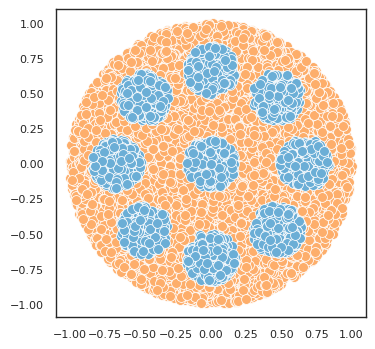

In [184]:
# Dataset config
dataset_config = DatasetConfig(
    dataset_name="SunflowerDataset",
    num_samples=8_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
train_dataset = DatasetClass(config=dataset_config)

# Figure and plot
fig, ax = plt.subplots()
labels = [0, 1]
colors = [
    aesthetics.SeabornColors.orange,
    aesthetics.SeabornColors.blue,
]
for i, label in enumerate(labels):
    sns.scatterplot(
        x=train_dataset.features[train_dataset.labels.squeeze() == label, 0].numpy(),
        y=train_dataset.features[train_dataset.labels.squeeze() == label, 1].numpy(),
        ax=ax,
        color=colors[i],
        marker="o",
        s=50,
    )

plt.show()

In [232]:
target_class = 0
idx = torch.where(train_dataset.labels == target_class)[0]
subset = Subset(train_dataset, idx)

# Create data loaders
loader = torch.utils.data.DataLoader(subset, batch_size=1_024, shuffle=False)
data, labels = next(iter(loader))


In [233]:
# data, top_components = perform_pca(data.flatten(1), 50)

In [242]:
distance_matrix = geodesic_distance_matrix(data, k=15)

In [243]:
torch.topk(torch.unique(distance_matrix.flatten()), k=5)

torch.return_types.topk(
values=tensor([20., 19., 18., 17., 16.]),
indices=tensor([20, 19, 18, 17, 16]))

In [244]:
# # Apply MDS to reduce to 2D
# mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
# embedding = mds.fit_transform(distance_matrix.numpy())

# # Plot using seaborn
# sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1])
# plt.show()

In [245]:
maxdim = 1

In [246]:
# Convert to gtda format
# normalized_distance_matrix = distance_matrix / torch.max(distance_matrix)
dgm = ripser_parallel(
    distance_matrix.numpy(),
    metric="precomputed",
    maxdim=maxdim,
    n_threads=-1,
    # thresh=0.9,
)
dgm_gtda = _postprocess_diagrams([dgm["dgms"]], "ripser", list(range(maxdim + 1)), np.inf, True)[0]
plot_diagram(dgm_gtda)

In [247]:
dgm.keys()

dict_keys(['dgms'])

In [248]:
def calculate_betti_numbers(dgm_array, threshold):
    """
    Calculate Betti numbers given a birth-death diagram and a threshold value.

    Parameters:
    - dgm_array: A numpy array of shape (N, 3) where each row is (birth, death, dimension)
    - threshold: The threshold value to consider for Betti numbers

    Returns:
    - A dictionary of Betti numbers for each dimension
    """
    betti_numbers = {}

    dim = int(dgm_gtda[-1][-1])

    # Iterate over each dimension present in the data
    complexity = 0
    for k in range(dim + 1):
        # Filter features of dimension k
        features_k = dgm_array[dgm_array[:, 2] == k]

        # Count features that are alive at the threshold (death > threshold)
        alive_features = np.sum((features_k[:, 0] <= threshold) & (features_k[:, 1] > threshold))
        complexity += alive_features

        # Store the Betti number for dimension k
        betti_numbers[f"beta_{k}"] = alive_features

    betti_numbers["complexity"] = complexity

    return betti_numbers

In [251]:
calculate_betti_numbers(dgm_gtda, 2)

{'beta_0': 0, 'beta_1': 9, 'complexity': 9}